<a href="https://colab.research.google.com/github/GeraldL19/Final-Year-Project-2024/blob/main/Data_gathering_and_preprocessing_trial_23_09_2023.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Experimenting with the 'ashraq/financial-news-articles' dataset from hugging face.

Experience with Pandas dataframe manipulation and data cleaning.

Extracting topic words from text in order to find relevant article.



In [ ]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
# nltk imports
from nltk.tokenize import word_tokenize  # tokenize the text == the text is splitted into words in list
from nltk.corpus import stopwords  # this contain common stop words that has no effect in analysis
from nltk.stem import WordNetLemmatizer  # Lemmatization is the process of grouping together the different inflected forms of a word so they can be analyzed as a single item

# download nltk corpus (first time only)
import nltk

nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package basque_grammars to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping grammars/basque_grammars.zip.
[nltk_data]    | Downloading package bcp47 to /root/nltk_data...
[nltk_data]    | Downloading package biocreative_ppi to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   U

True

In [ ]:
!pip install datasets
from datasets import load_dataset
import pandas as pd

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.6/519.6 kB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 7.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 9.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 7.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.0/295.0 kB 10.7 MB/s eta 0:00:00


In [ ]:
dataset = load_dataset("ashraq/financial-news-articles")

Extracting data files:   0%|          | 0/1 [00:00<?, ?it/s]

Generating train split:   0%|          | 0/306242 [00:00<?, ? examples/s]

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['title', 'text', 'url'],
        num_rows: 306242
    })
})

In [ ]:
df = dataset['train'].to_pandas()

In [ ]:
df

,title,text,url
0,BRIEF-Bigger Capital Fund Reports An 8 Pct Pas...,"January 2, 2018 / 9:31 PM / Updated 8 minutes ...",https://www.reuters.com/article/brief-bigger-c...
1,Global Markets: Asia shares reach decade top o...,NEW YORK (Reuters) - European stocks closed lo...,https://in.reuters.com/article/global-markets/...
2,Donald Trump is the only person in Washington ...,Fears of a government shutdown coursed through...,https://www.cnbc.com/2018/01/18/donald-trump-t...
3,Actor Casey Affleck withdraws as 2018 Oscar pr...,03 PM / Updated 19 minutes ago Actor Casey Af...,https://www.reuters.com/article/us-oscars-case...
4,EU mulls new link between budget and civic rights,"January 22, 2018 / 7:23 PM / Updated 2 hours a...",https://uk.reuters.com/article/uk-eu-poland-bu...
...,...,...,...
306237,British gaming firm enlists army of players to...,"May 17, 2018 / 10:22 AM / Updated 39 minutes a...",https://www.reuters.com/article/us-videogames-...
306238,Norway plans to auction new salmon production ...,"OSLO, May 18 (Reuters) - The Norwegian governm...",https://www.reuters.com/article/norway-salmon/...
306239,JMU Limited Reports Unaudited First Quarter 20...,"SHANGHAI, May 31, 2018 /PRNewswire/ -- JMU Lim...",http://www.cnbc.com/2018/05/31/pr-newswire-jmu...
306240,Apple will reportedly introduce new software t...,"Adam Jeffery | CNBC Tim Cook, CEO of Apple Inc...",https://www.cnbc.com/2018/05/31/apple-digital-...


In [ ]:
df2=df['url'].str.split('.com/', expand=True)

In [ ]:
df3=df2[0].str.split('.', expand=True)

In [ ]:
extracted_col = df3[1]

In [ ]:
df = df.join(extracted_col)

In [ ]:
df.rename(columns = {1:'website'}, inplace = True)

In [ ]:
unique_web = df.website.unique()
unique_web

array(['reuters', 'cnbc', None, 'wsj', 'com'], dtype=object)

In [ ]:
df.head()

,title,text,url,website
0,BRIEF-Bigger Capital Fund Reports An 8 Pct Pas...,"January 2, 2018 / 9:31 PM / Updated 8 minutes ...",https://www.reuters.com/article/brief-bigger-c...,reuters
1,Global Markets: Asia shares reach decade top o...,NEW YORK (Reuters) - European stocks closed lo...,https://in.reuters.com/article/global-markets/...,reuters
2,Donald Trump is the only person in Washington ...,Fears of a government shutdown coursed through...,https://www.cnbc.com/2018/01/18/donald-trump-t...,cnbc
3,Actor Casey Affleck withdraws as 2018 Oscar pr...,03 PM / Updated 19 minutes ago Actor Casey Af...,https://www.reuters.com/article/us-oscars-case...,reuters
4,EU mulls new link between budget and civic rights,"January 22, 2018 / 7:23 PM / Updated 2 hours a...",https://uk.reuters.com/article/uk-eu-poland-bu...,reuters


<Axes: >

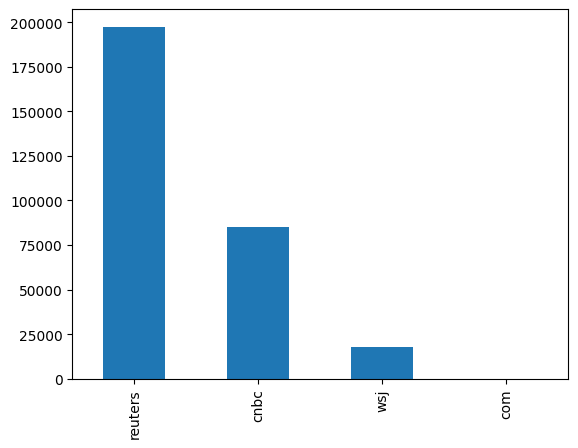

In [27]:
df.website.value_counts().plot.bar()

In [42]:
words = ['GHG emission', 'Biodiversity', 'Climate change', 'Renewable energy', 'Energy efficiency', 'Air quality', 'Water depletion', 'pollution', 'Resource depletion', 'Waste management', 'Ozone depletion', 'land use', 'Ocean acidification', 'nitrogen', 'phosphorous cycles', 'No Poverty', 'Zero Hunger', 'Good Health', 'Well-being', 'Quality Education', 'Clean water', 'Sanitation', 'Affordable', 'Clean Energy', 'Decent Work', 'Reduced Inequality', 'Sustainable Cities', 'Responsible Consumption', 'Climate Action', 'Life Below Water', 'Life On Land']

In [54]:
df_1 = df

In [55]:
df_1

,title,text,url,website
0,BRIEF-Bigger Capital Fund Reports An 8 Pct Pas...,"January 2, 2018 / 9:31 PM / Updated 8 minutes ...",https://www.reuters.com/article/brief-bigger-c...,reuters
1,Global Markets: Asia shares reach decade top o...,NEW YORK (Reuters) - European stocks closed lo...,https://in.reuters.com/article/global-markets/...,reuters
2,Donald Trump is the only person in Washington ...,Fears of a government shutdown coursed through...,https://www.cnbc.com/2018/01/18/donald-trump-t...,cnbc
3,Actor Casey Affleck withdraws as 2018 Oscar pr...,03 PM / Updated 19 minutes ago Actor Casey Af...,https://www.reuters.com/article/us-oscars-case...,reuters
4,EU mulls new link between budget and civic rights,"January 22, 2018 / 7:23 PM / Updated 2 hours a...",https://uk.reuters.com/article/uk-eu-poland-bu...,reuters
...,...,...,...,...
306237,British gaming firm enlists army of players to...,"May 17, 2018 / 10:22 AM / Updated 39 minutes a...",https://www.reuters.com/article/us-videogames-...,reuters
306238,Norway plans to auction new salmon production ...,"OSLO, May 18 (Reuters) - The Norwegian governm...",https://www.reuters.com/article/norway-salmon/...,reuters
306239,JMU Limited Reports Unaudited First Quarter 20...,"SHANGHAI, May 31, 2018 /PRNewswire/ -- JMU Lim...",http://www.cnbc.com/2018/05/31/pr-newswire-jmu...,cnbc
306240,Apple will reportedly introduce new software t...,"Adam Jeffery | CNBC Tim Cook, CEO of Apple Inc...",https://www.cnbc.com/2018/05/31/apple-digital-...,cnbc


In [56]:
df_1['c'] = df_1.text.str.findall('({0})'.format('|'.join(words)), flags=re.IGNORECASE)
df_1['d'] = df_1['c'].str.len()

In [52]:
df_2 = df_1[df_1.d != 0]

In [53]:
df_2

,title,text,url,website,c,d
14,"Trump, Lighthizer discuss China, NAFTA trade t...","PALM BEACH, Florida (Reuters) - President Dona...",https://www.reuters.com/article/us-usa-trade-n...,reuters,[pollution],1
49,"Freed from Libyan jails, frustrated migrants p...","BANJUL (Thomson Reuters Foundation) - Jobless,...",https://www.reuters.com/article/us-gambia-migr...,reuters,[climate change],1
78,Philippines' president made call on China's se...,"MANILA, Jan 15 (Reuters) - Philippine Presiden...",https://www.reuters.com/article/philippines-ch...,reuters,[biodiversity],1
93,Hollywood stars back #TimesUp war on harassmen...,LONDON (Thomson Reuters Foundation) - Hollywoo...,https://www.reuters.com/article/us-women-haras...,reuters,[climate change],1
102,China December factory growth quickens to four...,BEIJING (Reuters) - Growth in China’s manufact...,https://in.reuters.com/article/china-economy-p...,reuters,[pollution],1
...,...,...,...,...,...,...
99874,EU should raise fossil fuel taxes to plug Brex...,"February 21, 2018 / 12:50 PM / Updated 8 hours...",https://www.reuters.com/article/us-eu-budget-c...,reuters,"[climate change, pollution]",2
99893,Trump proposes reduction of drug costs under M...,WASHINGTON (AP) — President Donald Trump will ...,https://www.cnbc.com/2018/02/09/the-associated...,cnbc,"[Affordable, Affordable]",2
99929,Quidel Reports Fourth Quarter and Full Year 20...,SAN DIEGO--(BUSINESS WIRE)-- Quidel Corporatio...,http://www.cnbc.com/2018/02/21/business-wire-q...,cnbc,[well-being],1
99944,Watsco Boosts Annual Dividend 16% to $5.80 Per...,"MIAMI, Feb. 08, 2018 (GLOBE NEWSWIRE) -- Watsc...",http://www.cnbc.com/2018/02/08/globe-newswire-...,cnbc,[energy efficiency],1


<Axes: >

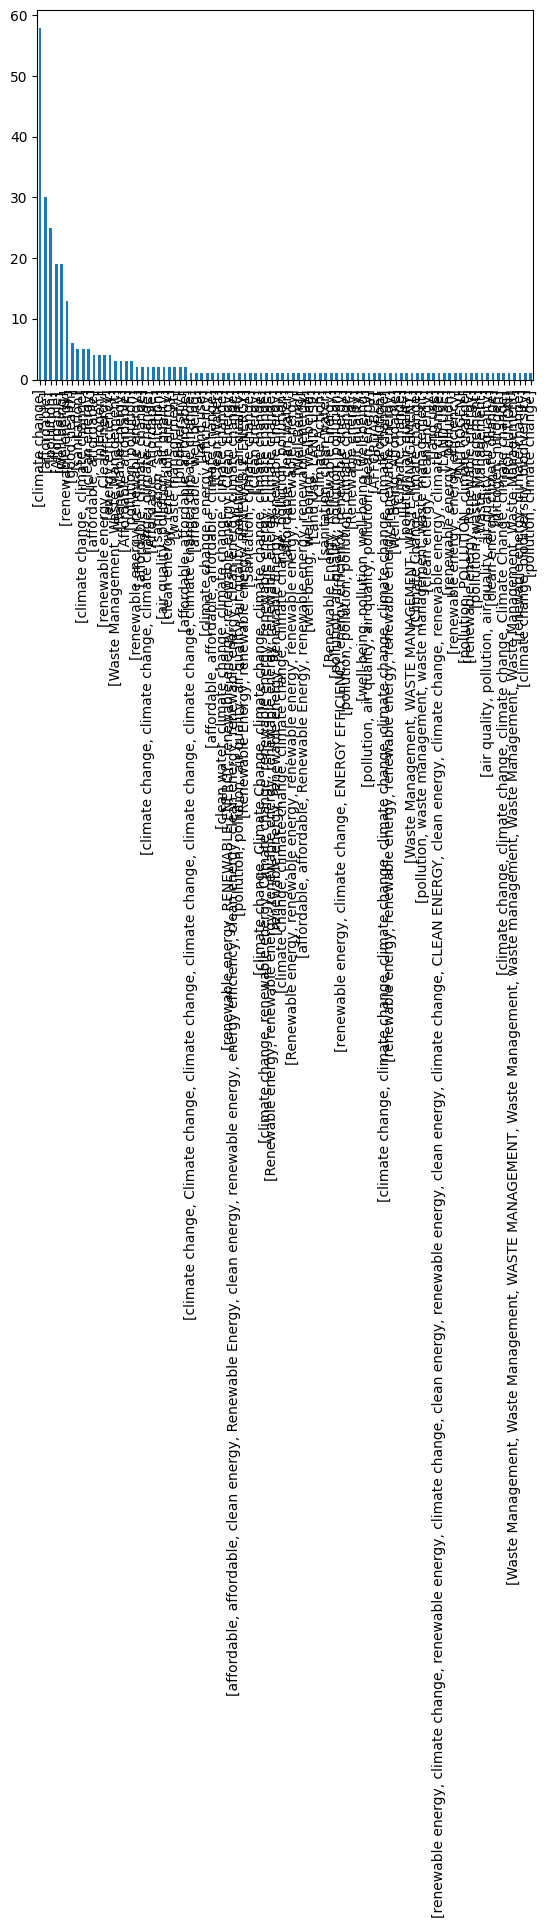

In [48]:
df_2.c.value_counts().plot.bar()